# RLHF & DPO from scratch — the two preference-optimization losses

This notebook is the runnable companion to the **[RLHF & DPO](../15-RLHF-and-DPO.md)** concept
page. It builds, from scratch and deterministically, the two losses that power preference
alignment, and watches the gradients do exactly what the derivation on the page promises:

1. the **Bradley-Terry reward-model loss** `−log σ(r_w − r_l)` — and a tiny reward model trained
   with it, which we *assert* learns to score chosen answers above rejected ones;
2. the **DPO loss** `−log σ(β·[Δlogπ_chosen − Δlogπ_rejected])` and its gradient — and a measured
   toy DPO run where the chosen log-prob rises, the rejected one falls, and the implicit-reward
   margin grows step by step.

Every function is imported from [`rlhf_dpo.py`](rlhf_dpo.py) (the verified source of truth), so the
numbers here match the page, the script, and the figures exactly. It runs on CPU in a second; no
downloads, no GPU needed.

> **Distinct from the neighbours.** [SFT](../../13-Supervised-Fine-Tuning/13-Supervised-Fine-Tuning.md)
> learns from *demonstrations* (one target answer per prompt); [instruction tuning](../../14-Instruction-Tuning/14-Instruction-Tuning.md)
> is SFT at multitask scale. This page is about learning from **preferences** (A is better than B)
> to optimize fuzzy qualities — helpful / harmless / honest — that no single demonstration can teach.

## Setup and an honest device line

We import the canonical functions and print the device + torch version. The accelerator is
auto-detected (CUDA / MPS / CPU), but every demo here is **pinned to CPU** (`DEMO_DEVICE`) so the
printed numbers are bit-reproducible on any machine — float reductions differ in the last digits
across backends, so a reward scalar trained on MPS would not match one trained on CPU. The code
itself is fully device-agnostic (`make_preference_features` and `train_reward_model` both thread
`device` and call `.to(device)`); pass `rl.DEVICE` instead of `DEMO_DEVICE` to run on the real
accelerator — only the *asserted ranking* (chosen > rejected, 6/6) is then guaranteed, not the
last digits of the scalars. The honest line reports both.

In [1]:
import math
import torch

import rlhf_dpo as rl  # the verified source of truth: every number below comes from here

DEMO_DEVICE = "cpu"  # pin the printed tables to CPU for bit-reproducibility
print(f"device: {DEMO_DEVICE} (detected {rl.DEVICE}; pinned to CPU for reproducibility)")
print("torch:", torch.__version__)
print("beta (KL leash / preference temperature):", rl.BETA)

device: cpu (detected mps; pinned to CPU for reproducibility)
torch: 2.12.0
beta (KL leash / preference temperature): 0.1


## (a) The Bradley-Terry reward-model loss

RLHF's first job is to turn *orderings* (chosen ≻ rejected) into a *scalar* reward. The bridge is
the **Bradley-Terry** model: the probability a human prefers the chosen answer is the **logistic of
the reward gap**, `P(y_w ≻ y_l) = σ(r_w − r_l)`. Fitting it by maximum likelihood gives the
reward-model loss `L = −log σ(r_w − r_l)` — binary cross-entropy on the gap, so **only the gap
matters** (adding a constant to every reward changes nothing — the Elo property).

We reproduce the page's three worked rows: a confident-correct pair (gap +3), a tie (gap 0), and a
backwards pair (gap −3). Note the tie gives loss `log 2 = 0.6931`, the maximum-uncertainty point.

In [2]:
print("Bradley-Terry RM loss  (gap -> P(chosen>rejected) -> loss):")
for row in rl.bt_worked_examples():
    print(f"  r_w={row['r_w']:+.1f} r_l={row['r_l']:+.1f}  "
          f"gap={row['gap']:+.1f}  P={row['P']:.4f}  loss={row['loss']:.4f}")

Bradley-Terry RM loss  (gap -> P(chosen>rejected) -> loss):
  r_w=+2.0 r_l=-1.0  gap=+3.0  P=0.9526  loss=0.0486
  r_w=+0.0 r_l=+0.0  gap=+0.0  P=0.5000  loss=0.6931
  r_w=-1.0 r_l=+2.0  gap=-3.0  P=0.0474  loss=3.0486


## (b) Train a tiny reward model with the Bradley-Terry loss

Now the loss does real work. We model a reward model as its only *new* trainable piece — a single
scalar **value head** `Linear(FEAT_DIM, 1)` over a pooled-embedding stand-in (the SFT body already
"understands" language; only the head plus a light fine-tune are new). We feed it a handful of
synthetic preference pairs (chosen features cluster positive, rejected negative) and train with
`−log σ(r_chosen − r_rejected)`.

First, the shapes — always print them so the tensor plumbing is explicit.

In [3]:
chosen, rejected = rl.make_preference_features(device=DEMO_DEVICE)  # CPU-pinned for reproducibility
print("chosen  features:", tuple(chosen.shape), "  (N_PAIRS, FEAT_DIM)")
print("rejected features:", tuple(rejected.shape))
print("a reward model maps each (FEAT_DIM,) row -> one scalar reward")

chosen  features: (6, 8)   (N_PAIRS, FEAT_DIM)
rejected features: (6, 8)
a reward model maps each (FEAT_DIM,) row -> one scalar reward


Train for 200 steps and read the before/after. The assertion is the lesson: after training the
mean **chosen** reward sits *above* the mean **rejected** reward and *every* pair is ranked
correctly — the reward model learned the ranking from **comparisons alone**, never an absolute score.

In [4]:
reward_head, stats = rl.train_reward_model(chosen, rejected, device=DEMO_DEVICE)  # CPU-pinned
b, a = stats["before"], stats["after"]
print(f"before: mean r(chosen)={b['chosen']:+.3f}  mean r(rejected)={b['rejected']:+.3f}  loss={b['loss']:.4f}")
print(f"after : mean r(chosen)={a['chosen']:+.3f}  mean r(rejected)={a['rejected']:+.3f}  loss={a['loss']:.4f}")
print(f"pairs scored chosen > rejected: {a['n_correct']}/{rl.N_PAIRS}")

# Assert the reward model learned the ranking -- the whole point of stage 1.
assert a["chosen"] > a["rejected"], "reward model must score chosen above rejected"
assert a["n_correct"] == rl.N_PAIRS, "every pair must be ranked correctly"
assert a["loss"] < b["loss"], "Bradley-Terry loss must decrease"
print("OK: reward model ranks chosen above rejected (asserted)")

before: mean r(chosen)=-0.199  mean r(rejected)=+0.083  loss=0.8494
after : mean r(chosen)=+3.936  mean r(rejected)=-3.730  loss=0.0006
pairs scored chosen > rejected: 6/6
OK: reward model ranks chosen above rejected (asserted)


## (c) The DPO loss and its gradient at initialization

DPO drops the reward model entirely. The page's derivation shows the optimal KL-constrained RLHF
policy encodes the reward as the **implicit reward** `β·log(π/π_ref)`; substituting that into the
Bradley-Terry loss (the prompt-only partition function cancels between the two completions) gives:

$$\mathcal{L}_{\text{DPO}} = -\log\sigma\Big(\beta\big[\log\tfrac{\pi(y_w)}{\pi_{\text{ref}}(y_w)} - \log\tfrac{\pi(y_l)}{\pi_{\text{ref}}(y_l)}\big]\Big).$$

Start training **from the SFT model**, so the policy *equals* the reference: every log-ratio is 0,
the margin is 0, and the loss is exactly `log 2`. One backward pass shows the gradient **pushes the
chosen log-prob up** (negative grad) and the **rejected log-prob down** (positive grad).

In [5]:
init = rl.dpo_init_gradient()
print(f"DPO at init (policy == reference): loss = {init['loss']:.4f}  = log 2 (no preference yet)")
print(f"  d loss / d logp(chosen)   = {init['grad_chosen']:+.4f}  -> training PUSHES chosen UP")
print(f"  d loss / d logp(rejected) = {init['grad_rejected']:+.4f}  -> training PUSHES rejected DOWN")

assert init["grad_chosen"] < 0, "gradient must raise the chosen log-prob"
assert init["grad_rejected"] > 0, "gradient must lower the rejected log-prob"
assert abs(init["loss"] - math.log(2)) < 1e-6, "init loss must equal log 2"
print("OK: gradient direction matches the derivation (asserted)")

DPO at init (policy == reference): loss = 0.6931  = log 2 (no preference yet)
  d loss / d logp(chosen)   = -0.0500  -> training PUSHES chosen UP
  d loss / d logp(rejected) = +0.0500  -> training PUSHES rejected DOWN
OK: gradient direction matches the derivation (asserted)


### The margin progression

As training separates the two responses, the **implicit-reward margin** grows, the loss falls, and
`P(chosen ≻ rejected) = σ(margin)` rises from a coin flip toward certainty. This table reproduces
the page's worked-example table exactly (β = 0.1; the reference log-ratio is 0 at init, so the
margin is just `β·(Δchosen − Δrejected)`).

In [6]:
print("chosen Δ | rejected Δ | margin | DPO loss | P(chosen>rejected)")
print("-" * 60)
for row in rl.dpo_margin_table():
    print(f"  {row['d_w']:+5.0f}   |   {row['d_l']:+6.0f}   | {row['margin']:+5.2f}  "
          f"|  {row['loss']:.4f}  |      {row['P']:.4f}")

chosen Δ | rejected Δ | margin | DPO loss | P(chosen>rejected)
------------------------------------------------------------
     +0   |       +0   | +0.00  |  0.6931  |      0.5000
     +1   |       -1   | +0.20  |  0.5981  |      0.5498
     +2   |       -2   | +0.40  |  0.5130  |      0.5987
     +3   |       -3   | +0.60  |  0.4375  |      0.6457
     +5   |       -5   | +1.00  |  0.3133  |      0.7311


### The implicit reward and the adaptive gradient weight

Two quantities make DPO's mechanism concrete. The **implicit reward** `β·log(π/π_ref)` is the
reward DPO optimizes without ever building a reward model — a chosen log-prob 0.8 above the
reference is an implicit reward of `0.1 × 0.8 = +0.08`. And the gradient is scaled by the
**adaptive weight** `β·σ(−margin)` = *how wrong the model currently is*: large when the pair is
backwards, near zero once the model already prefers the chosen answer (so it spends its gradient
exactly where it's still wrong — the same self-correcting shape as the Bradley-Terry gradient).

In [7]:
print("Implicit reward  beta*log(pi/pi_ref)  for the chosen response:")
for d_lp in (0.0, 0.8, 2.0):
    ir = rl.implicit_reward(rl.REF_LOGPROB + d_lp, rl.REF_LOGPROB)
    print(f"  chosen logprob {d_lp:+.1f} above reference -> implicit reward = {ir:+.3f}")

print("\nAdaptive gradient weight  beta*sigma(-margin)  (big when the model is wrong):")
for m in (-2.0, 0.0, 2.0):
    weight = rl.BETA * (1.0 / (1.0 + math.exp(m)))  # beta * sigma(-m)
    print(f"  margin={m:+.1f}: weight={weight:.4f}")

Implicit reward  beta*log(pi/pi_ref)  for the chosen response:
  chosen logprob +0.0 above reference -> implicit reward = +0.000
  chosen logprob +0.8 above reference -> implicit reward = +0.080
  chosen logprob +2.0 above reference -> implicit reward = +0.200

Adaptive gradient weight  beta*sigma(-margin)  (big when the model is wrong):
  margin=-2.0: weight=0.0881
  margin=+0.0: weight=0.0500
  margin=+2.0: weight=0.0119


## (d) A measured toy DPO run — the derivation, watched happening

Finally, optimize a tiny two-log-prob "policy" (just `log π(chosen)` and `log π(rejected)`, both
starting **at** the frozen reference) under the DPO loss for 120 steps. We assert the four things
the derivation promises: the chosen log-prob **rises**, the rejected one **falls**, the
implicit-reward **margin grows**, and the loss **falls**. This is the exact run plotted in
`dpo_update.png`.

In [8]:
history = rl.run_toy_dpo()
print("step | chosen logp | rejected logp |  margin  | DPO loss")
print("-" * 56)
for s in (0, 40, 80, 120):
    i = history["step"].index(s)
    print(f" {s:3d} |   {history['chosen'][i]:+7.3f}  |   {history['rejected'][i]:+8.3f}   "
          f"| {history['margin'][i]:+.4f} |  {history['loss'][i]:.4f}")

# Assert the derivation's promise -- BEFORE we celebrate the plot.
assert history["chosen"][-1] > history["chosen"][0], "chosen log-prob must rise"
assert history["rejected"][-1] < history["rejected"][0], "rejected log-prob must fall"
assert history["margin"][-1] > history["margin"][0], "implicit-reward margin must grow"
assert history["loss"][-1] < history["loss"][0], "DPO loss must fall"

final_ir = rl.implicit_reward(history["chosen"][-1], rl.REF_LOGPROB)
print(f"\nfinal implicit reward for chosen = beta*log(pi/pi_ref) = {final_ir:+.3f}")
print("OK: chosen up, rejected down, margin grows, loss falls (asserted)")

step | chosen logp | rejected logp |  margin  | DPO loss
--------------------------------------------------------
   0 |    -5.000  |     -5.000   | +0.0000 |  0.6931
  40 |    -1.678  |     -8.322   | +0.6644 |  0.4151
  80 |    +0.636  |    -10.636   | +1.1272 |  0.2806
 120 |    +2.350  |    -12.350   | +1.4701 |  0.2069

final implicit reward for chosen = beta*log(pi/pi_ref) = +0.735
OK: chosen up, rejected down, margin grows, loss falls (asserted)


### See it: the two log-probs separate while the margin grows

The same recorded trajectory, plotted. Left: the chosen and rejected log-probs split apart from
their shared reference start. Right: the implicit-reward margin climbs while the DPO loss decays —
the `dpo_update.png` figure on the page, reproduced live from this run.

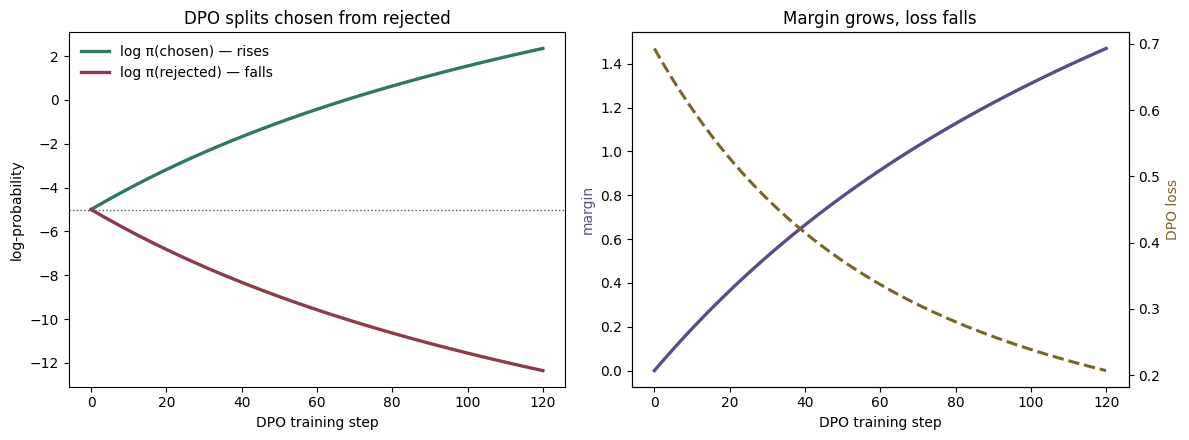

In [9]:
import matplotlib.pyplot as plt

steps = history["step"]
fig, (ax_lp, ax_m) = plt.subplots(1, 2, figsize=(12, 4.5))

ax_lp.plot(steps, history["chosen"], color="#2E7A5A", lw=2.4, label="log π(chosen) — rises")
ax_lp.plot(steps, history["rejected"], color="#8B3B4A", lw=2.4, label="log π(rejected) — falls")
ax_lp.axhline(rl.REF_LOGPROB, color="#4A5B6E", ls=":", lw=1.0)
ax_lp.set_xlabel("DPO training step"); ax_lp.set_ylabel("log-probability")
ax_lp.set_title("DPO splits chosen from rejected"); ax_lp.legend(frameon=False)

ax_m.plot(steps, history["margin"], color="#5D4A8A", lw=2.4, label="implicit-reward margin")
ax_loss = ax_m.twinx()
ax_loss.plot(steps, history["loss"], color="#7A6528", ls="--", lw=2.2, label="DPO loss")
ax_m.set_xlabel("DPO training step"); ax_m.set_ylabel("margin", color="#5D4A8A")
ax_loss.set_ylabel("DPO loss", color="#7A6528")
ax_m.set_title("Margin grows, loss falls")
fig.tight_layout()
plt.show()

## Recap

- The **Bradley-Terry loss** `−log σ(r_w − r_l)` turns *orderings* into a *scalar* reward; a tiny
  reward model trained with it learns to rank chosen above rejected from comparisons alone.
- **DPO** replaces the explicit reward with the **implicit reward** `β·log(π/π_ref)` — its loss is
  the *same* Bradley-Terry sigmoid, so it needs **no reward model and no RL**, training offline like SFT.
- The DPO **gradient** mechanically raises the chosen response's probability and lowers the
  rejected one's, scaled by `β·σ(−margin)` — large when the model is wrong, tiny once it's right.
- In a measured run the chosen log-prob rises, the rejected falls, the margin grows, the loss
  decays — exactly the derivation, made visible.

For the **production** versions — `RewardTrainer`, `PPOTrainer`, `DPOTrainer` on a real
transformer, with data collection and a β-sweep — see the
[RLHF & Alignment workflow](../../../Practitioner-Workflows/RLHF-and-Alignment/RLHF-and-Alignment.md).
The full derivations (the closed-form optimal policy, the partition-function cancellation, the
gradient read-off) live on the [concept page](../15-RLHF-and-DPO.md).